# Cross-Dataset Evaluation

This notebook evaluates the trained AI-text detection models on an external dataset that was not used during training.

The purpose is to measure out-of-distribution generalization and determine whether the near-perfect performance observed on the original Kaggle test set transfers to text from a different source.

External dataset: Human ChatGPT Comparison Corpus (HC3).

In [1]:
%pip install datasets

   ---------------------------------------- 0.0/559.1 kB ? eta -:--:--
   ------------------ --------------------- 262.1/559.1 kB ? eta -:--:--
   ---------------------------------------- 559.1/559.1 kB 2.1 MB/s  0:00:00
   ---------------------------------------- 0.0/784.9 kB ? eta -:--:--
   -------------------------- ------------- 524.3/784.9 kB 2.8 MB/s eta 0:00:01
   ---------------------------------------- 784.9/784.9 kB 2.4 MB/s  0:00:00
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.5/4.0 MB 3.4 MB/s eta 0:00:02
   ------------ --------------------------- 1.3/4.0 MB 3.4 MB/s eta 0:00:01
   ------------------ --------------------- 1.8/4.0 MB 3.1 MB/s eta 0:00:01
   ------------------------- -------------- 2.6/4.0 MB 3.1 MB/s eta 0:00:01
   ------------------------------- -------- 3.1/4.0 MB 3.1 MB/s eta 0:00:01
   ------------------------------------ --- 3.7/4.0 MB 3.1 MB/s eta 0:00:01
   -----------------------

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import joblib
import matplotlib.pyplot as plt

from datasets import load_dataset

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [3]:
MODEL_DIR = Path("../models")
OUTPUT_DIR = Path("../outputs")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

log_reg = joblib.load(
    MODEL_DIR / "tfidf_logistic_regression_model.joblib"
)

log_tfidf = joblib.load(
    MODEL_DIR / "tfidf_vectorizer.joblib"
)

svm_model = joblib.load(
    MODEL_DIR / "tfidf_svm_model.joblib"
)

svm_tfidf = joblib.load(
    MODEL_DIR / "tfidf_svm_vectorizer.joblib"
)

print("Models loaded successfully.")

Models loaded successfully.


In [5]:
from datasets import load_dataset

hc3 = load_dataset(
    "json",
    data_files="hf://datasets/Hello-SimpleAI/HC3/all.jsonl"
)

hc3

all.jsonl: reconstructing file:   0%|          |  0.00B / 73.7MB            

all.jsonl: downloading bytes:           |  0.00B            

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['question', 'human_answers', 'chatgpt_answers', 'index', 'source'],
        num_rows: 24322
    })
})

In [6]:
print(hc3)
print(hc3["train"].column_names)
print("Rows:", len(hc3["train"]))

DatasetDict({
    train: Dataset({
        features: ['question', 'human_answers', 'chatgpt_answers', 'index', 'source'],
        num_rows: 24322
    })
})
['question', 'human_answers', 'chatgpt_answers', 'index', 'source']
Rows: 24322


In [7]:
hc3["train"][0]

{'question': 'Why is every book I hear about a " NY Times # 1 Best Seller " ? ELI5 : Why is every book I hear about a " NY Times # 1 Best Seller " ? Should n\'t there only be one " # 1 " best seller ? Please explain like I\'m five.',
 'human_answers': ['Basically there are many categories of " Best Seller " . Replace " Best Seller " by something like " Oscars " and every " best seller " book is basically an " oscar - winning " book . May not have won the " Best film " , but even if you won the best director or best script , you \'re still an " oscar - winning " film . Same thing for best sellers . Also , IIRC the rankings change every week or something like that . Some you might not be best seller one week , but you may be the next week . I guess even if you do n\'t stay there for long , you still achieved the status . Hence , # 1 best seller .',
  "If you 're hearing about it , it 's because it was a very good or very well - publicized book ( or both ) , and almost every good or well 

In [8]:
rows = []

for item in hc3["train"]:

    for answer in item["human_answers"]:
        if answer and answer.strip():
            rows.append({
                "text": answer.strip(),
                "generated": 0
            })

    for answer in item["chatgpt_answers"]:
        if answer and answer.strip():
            rows.append({
                "text": answer.strip(),
                "generated": 1
            })

hc3_df = pd.DataFrame(rows)

hc3_df.head()

,text,generated
0,"Basically there are many categories of "" Best ...",0
1,"If you 're hearing about it , it 's because it...",0
2,"One reason is lots of catagories . However , h...",0
3,There are many different best seller lists tha...,1
4,salt is good for not dying in car crashes and ...,0


In [9]:
print("Shape:", hc3_df.shape)

print("\nClass counts:")
print(hc3_df["generated"].value_counts())

print("\nClass percentages:")
print(hc3_df["generated"].value_counts(normalize=True) * 100)

Shape: (85431, 2)

Class counts:
generated
0    58546
1    26885
Name: count, dtype: int64

Class percentages:
generated
0    68.530159
1    31.469841
Name: proportion, dtype: float64


In [10]:
print("Missing:")
print(hc3_df.isnull().sum())

print("\nDuplicate texts:")
print(hc3_df["text"].duplicated().sum())

Missing:
text         0
generated    0
dtype: int64

Duplicate texts:
6100


In [11]:
hc3_df = hc3_df.drop_duplicates(
    subset=["text"]
).reset_index(drop=True)

print("After duplicate removal:", hc3_df.shape)

After duplicate removal: (79331, 2)


In [12]:
hc3_df["text_length"] = hc3_df["text"].str.len()

hc3_df["text_length"].describe()

count    79331.000000
mean       795.312614
std        729.966903
min          5.000000
25%        300.000000
50%        650.000000
75%       1096.000000
max      36793.000000
Name: text_length, dtype: float64

In [13]:
hc3_df.groupby("generated")["text_length"].describe()

,count,mean,std,min,25%,50%,75%,max
generated,,,,,,,,
0,53086.0,686.633745,833.747437,5.0,213.0,427.0,836.0,36793.0
1,26245.0,1015.138350,363.864839,16.0,758.0,1015.0,1244.0,3508.0


In [14]:
X_external_log = log_tfidf.transform(
    hc3_df["text"]
)

logistic_external_preds = log_reg.predict(
    X_external_log
)

logistic_external_probs = log_reg.predict_proba(
    X_external_log
)[:, 1]

y_external = hc3_df["generated"]

In [15]:
logistic_external_results = {
    "accuracy": accuracy_score(
        y_external,
        logistic_external_preds
    ),
    "precision": precision_score(
        y_external,
        logistic_external_preds,
        zero_division=0
    ),
    "recall": recall_score(
        y_external,
        logistic_external_preds,
        zero_division=0
    ),
    "f1": f1_score(
        y_external,
        logistic_external_preds,
        zero_division=0
    ),
    "roc_auc": roc_auc_score(
        y_external,
        logistic_external_probs
    )
}

logistic_external_results

{'accuracy': 0.4697533120722038,
 'precision': 0.3781840022176364,
 'recall': 0.9356829872356639,
 'f1': 0.5386547340944735,
 'roc_auc': 0.7583035570408809}

In [16]:
X_external_svm = svm_tfidf.transform(
    hc3_df["text"]
)

svm_external_preds = svm_model.predict(
    X_external_svm
)

svm_external_scores = svm_model.decision_function(
    X_external_svm
)

In [17]:
svm_external_results = {
    "accuracy": accuracy_score(
        y_external,
        svm_external_preds
    ),
    "precision": precision_score(
        y_external,
        svm_external_preds,
        zero_division=0
    ),
    "recall": recall_score(
        y_external,
        svm_external_preds,
        zero_division=0
    ),
    "f1": f1_score(
        y_external,
        svm_external_preds,
        zero_division=0
    ),
    "roc_auc": roc_auc_score(
        y_external,
        svm_external_scores
    )
}

svm_external_results

{'accuracy': 0.561785430663927,
 'precision': 0.4220314473467445,
 'recall': 0.8784911411697466,
 'f1': 0.5701567832237004,
 'roc_auc': 0.7641257549020178}

In [18]:
print("LOGISTIC REGRESSION — HC3")
print(
    classification_report(
        y_external,
        logistic_external_preds,
        target_names=["Human", "AI"]
    )
)

print("\nSVM — HC3")
print(
    classification_report(
        y_external,
        svm_external_preds,
        target_names=["Human", "AI"]
    )
)

LOGISTIC REGRESSION — HC3
              precision    recall  f1-score   support

       Human       0.88      0.24      0.38     53086
          AI       0.38      0.94      0.54     26245

    accuracy                           0.47     79331
   macro avg       0.63      0.59      0.46     79331
weighted avg       0.72      0.47      0.43     79331


SVM — HC3
              precision    recall  f1-score   support

       Human       0.87      0.41      0.55     53086
          AI       0.42      0.88      0.57     26245

    accuracy                           0.56     79331
   macro avg       0.65      0.64      0.56     79331
weighted avg       0.72      0.56      0.56     79331



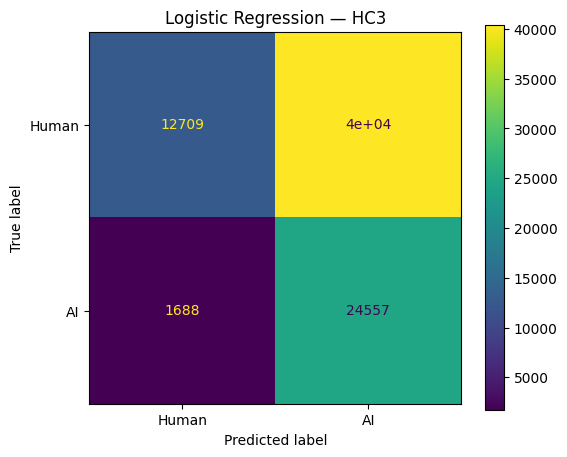

In [19]:
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_external,
    logistic_external_preds,
    display_labels=["Human", "AI"],
    ax=ax
)

plt.title("Logistic Regression — HC3")
plt.show()

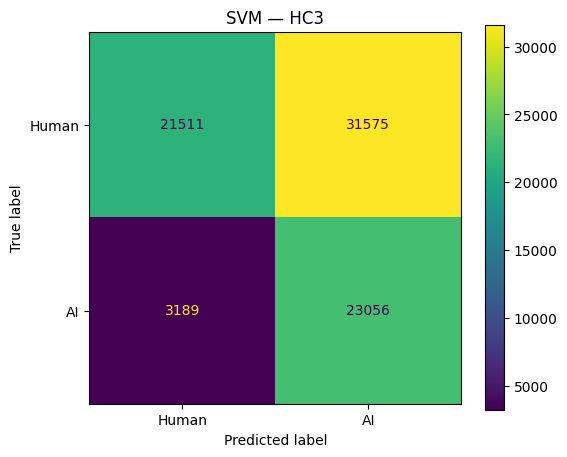

In [20]:
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_external,
    svm_external_preds,
    display_labels=["Human", "AI"],
    ax=ax
)

plt.title("SVM — HC3")
plt.show()

In [21]:
comparison_df = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Dataset": "Original Test",
        "F1": 0.993275
    },
    {
        "Model": "Logistic Regression",
        "Dataset": "HC3 External",
        "F1": logistic_external_results["f1"]
    },
    {
        "Model": "SVM",
        "Dataset": "Original Test",
        "F1": 0.999155
    },
    {
        "Model": "SVM",
        "Dataset": "HC3 External",
        "F1": svm_external_results["f1"]
    }
])

comparison_df

,Model,Dataset,F1
0,Logistic Regression,Original Test,0.993275
1,Logistic Regression,HC3 External,0.538655
2,SVM,Original Test,0.999155
3,SVM,HC3 External,0.570157


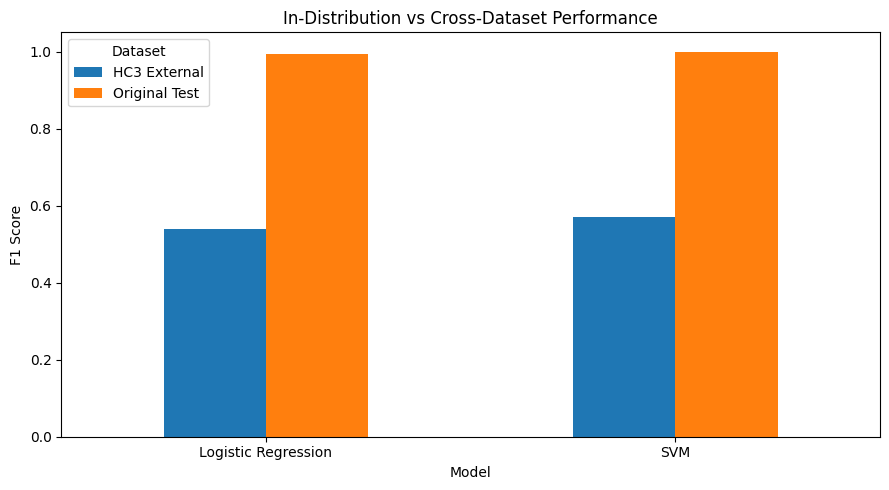

In [22]:
comparison_pivot = comparison_df.pivot(
    index="Model",
    columns="Dataset",
    values="F1"
)

comparison_pivot.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.ylabel("F1 Score")
plt.xlabel("Model")
plt.title("In-Distribution vs Cross-Dataset Performance")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [23]:
logistic_drop = (
    0.993275 - logistic_external_results["f1"]
)

svm_drop = (
    0.999155 - svm_external_results["f1"]
)

print(
    f"Logistic Regression absolute F1 drop: "
    f"{logistic_drop:.4f}"
)

print(
    f"SVM absolute F1 drop: "
    f"{svm_drop:.4f}"
)

print(
    f"\nLogistic relative F1 decrease: "
    f"{(logistic_drop / 0.993275) * 100:.2f}%"
)

print(
    f"SVM relative F1 decrease: "
    f"{(svm_drop / 0.999155) * 100:.2f}%"
)

Logistic Regression absolute F1 drop: 0.4546
SVM absolute F1 drop: 0.4290

Logistic relative F1 decrease: 45.77%
SVM relative F1 decrease: 42.94%
